In [3]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [4]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELS     = CONFIGS['experiments']
VARLABELS  = {
    'rh':'RH',
    'thetae':r'$\mathit{\theta_{e}}$',
    'thetaestar':r'$\mathit{\theta_{e}}^*$'}

In [5]:
with xr.open_dataset(f'{SPLITSDIR}/train.h5',engine='h5netcdf') as ds:
    sig = ds['sig'].load()

results = []
for name in MODELS['nn']['runs']:
    if 'nonparam' in name or 'gauss' in name:
        klist = []
        for seed in MODELS['nn']['seeds']:
            filepath = os.path.join(WEIGHTSDIR,f'{name}_{seed}_weights.nc')
            with xr.open_dataset(filepath,engine='h5netcdf') as ds:
                klist.append(ds.k.load())
        k = xr.concat(klist,dim='seed')
        kmean = k.mean('seed')
        kstd  = k.std('seed')
        results.append((name,kmean,kstd))

print(f'Found {len(results)} kernel models with saved weights!')

Found 2 kernel models with saved weights!


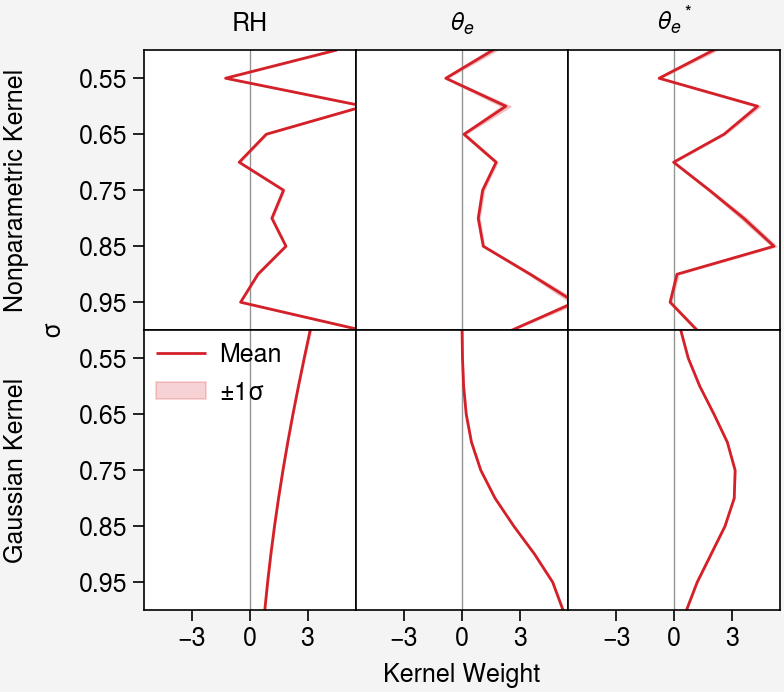

In [6]:
rowlabels = ['Nonparametric Kernel','Gaussian Kernel']
collabels = [v for v in VARLABELS.values()]
fig,axs = pplt.subplots(nrows=len(results),ncols=len(VARLABELS),figwidth=4,refheight=1.4,share=True,space=0)
axs.format(grid=False,rowlabels=rowlabels,collabels=collabels,xlabel='Kernel Weight',
           ylabel='$\\sigma$',ylim=(1,0.5),yticks=[0.95,0.85,0.75,0.65,0.55])
for row,(name,*data) in enumerate(results):
    for col in range(len(collabels)):
        ax = axs[row,col]
        if row!=len(rowlabels)-1:
            ax.tick_params(axis='x',bottom=False,labelbottom=False)
        if col!=0:
            ax.tick_params(axis='y',left=False,labelleft=False)
        ax.axvline(0,color='gray',linewidth=0.5)
        mean,std = data[0].isel(field=col),data[1].isel(field=col)
        ax.plot(mean,sig,color='#D42028',linewidth=1,label='Mean')
        ax.fill_betweenx(sig,mean-std,mean+std,color='#D42028',alpha=0.2,label=r'$\pm 1\sigma$')
        ax.format(xlim=(-5.5,5.5),xticks=3)
axs[1,0].legend(loc='ul',ncols=1,frame=False)
pplt.show()
fig.save('../figs/fig_S1.jpg')

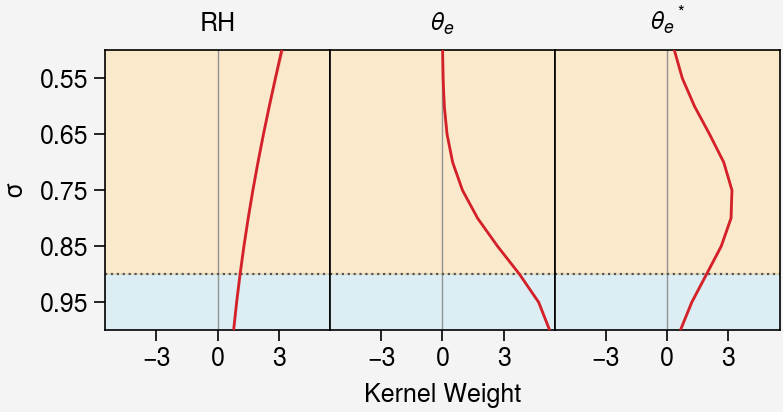

In [7]:
gauss     = next(r for r in results if 'gauss' in r[0])
gaussmean = gauss[1]
gaussstd  = gauss[2]
bltop  = 0.9
lfttop = 0.5
fig,axs = pplt.subplots(ncols=len(VARLABELS),figwidth=4,refheight=1.4,share=True,space=0)
axs.format(grid=False,collabels=list(VARLABELS.values()),xlabel='Kernel Weight',
           ylabel=r'$\sigma$',ylim=(1,0.5),yticks=[0.95,0.85,0.75,0.65,0.55])
for col,varkey in enumerate(VARLABELS):
    ax = axs[col]
    inlegend = col==0
    if col!=0:
        ax.tick_params(axis='y',left=False,labelleft=False)
    ax.axhspan(bltop,1.0,color='#a8d5e5',alpha=0.4,
               label='Boundary layer (Ahmed et al.)' if inlegend else '_',zorder=0)
    ax.axhspan(lfttop,bltop,color='#f5c97f',alpha=0.4,
               label='Lower free troposphere (Ahmed et al.)' if inlegend else '_',zorder=0)
    ax.axvline(0,color='gray',linewidth=0.5)
    ax.axhline(bltop,color='#555',lw=0.8,ls=':',zorder=2)
    mean = gaussmean.isel(field=col)
    std  = gaussstd.isel(field=col)
    ax.plot(mean,sig,color='#D42028',lw=1,
            label='Learned kernel' if inlegend else '_',zorder=5)
    ax.fill_betweenx(sig,mean-std,mean+std,color='#D42028',alpha=0.2,zorder=5)
    ax.format(xlim=(-5.5,5.5),xticks=3)
# fig.legend(loc='b',ncols=3,frame=False)
pplt.show()
fig.save('../figs/fig_2.jpg')

In [8]:
sigarr  = sig.values
dsigarr = np.abs(np.gradient(sigarr))
labels  = VARLABELS.values()

rows = []
for name,kmean,_ in results:
    if 'nonparam' in name:
        continue
    for i,varname in enumerate(labels):
        k      = kmean.isel(field=i).values
        pi     = np.argmax(k)
        center = float(sigarr[pi])
        width  = float(np.sqrt(((sigarr-center)**2*k*dsigarr).sum()))
        rows.append({'Predictor':varname,r'$\sigma_c$':round(center,2),r'$\sigma_w$':round(width,3)})

df = pd.DataFrame(rows)
display(df.style.hide(axis='index').format(precision=3))

Predictor,$\sigma_c$,$\sigma_w$
RH,0.500,0.237
$\mathit{\theta_{e}}$,1.000,0.130
$\mathit{\theta_{e}}^*$,0.750,0.117
